In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [2]:
df=pd.read_csv("development.csv")

In [3]:
binary_columns=['jobma_catcher_status',
                'jobma_catcher_type',
                'subscription_status',
                'jobma_login_status',
                'subscription_type',
                'referral_credit',
                'is_unlimited',
                'is_premium',
                'plan_type',
                'currency'
                ]

categorical_columns = ['company_size']

numerical_columns =['sub_user',
                    'catcher_id',
                    'wallet_sum',
                    'per_sub_user',
                    'number_of_logins',
                    'days_since_login',
                    'subscription_sum',
                    'subscription_count',
                    'premium_plan_id',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'number_of_invitations',
                    'number_of_pitcher_applied',
                    'pre_rec_interviews_counts',
                    'live_interviews_counts',
                    'ai_kit_counts',
                    'ai_interviews_counts'
                   ]

# Clean binary values ,
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

# Clean ordinal values
def clean_ordinal(X):
    return X.clip(lower=0)

def log_transform(X):
    X = np.asarray(X, dtype=float)
    X = np.clip(X, a_min=1e-10, a_max=None)
    return np.log(X)



#Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('scaler', StandardScaler())
                                 ])

#Categorical pipeline
categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

#Ordinal pipeline
numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(log_transform, validate=False)),
                                   ('scaler', StandardScaler())
                                  ])

#Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', numerical_pipeline, numerical_columns)
                                              ] )

#pipeline
pipeline = Pipeline([('preprocessing', preprocessor)])

In [4]:
# Step 1: Fit the pipeline to your data
pipeline.fit(df)
encoder = pipeline.named_steps['preprocessing'].transformers_[1][1].named_steps['encoder']
feature_names = list(encoder.get_feature_names_out(categorical_columns))

In [5]:
feature_names

['company_size_1-25',
 'company_size_101-500',
 'company_size_26-100',
 'company_size_500-1000',
 'company_size_more than 1000']

In [6]:
columns_after_transformation = binary_columns + feature_names + numerical_columns

In [7]:
processed_df = pipeline.transform(df)

In [8]:
processed_df = pd.DataFrame(processed_df, columns=columns_after_transformation)

In [9]:
processed_df.head()

,jobma_catcher_status,jobma_catcher_type,subscription_status,jobma_login_status,subscription_type,referral_credit,is_unlimited,is_premium,plan_type,currency,...,subscription_count,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
0,0.310962,0.346667,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,0.476081,0.029419,2.273266,2.920809,2.632492,3.907692,2.869721,8.267736,-0.035497,-0.023224
1,-3.215822,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,-0.445020,-0.380734,-0.352914,-0.341232,-0.116898,-0.035497,-0.023224
2,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,2.160826,-0.380734,2.780409,-0.341232,-0.116898,-0.035497,-0.023224
3,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,-0.445020,-0.380734,-0.352914,-0.341232,-0.116898,-0.035497,-0.023224
4,0.310962,-2.884616,0.0,4.979493,-0.032909,-0.038007,-0.410564,1.281488,-0.870543,-0.882442,...,-0.412142,0.029419,-0.440494,2.160826,-0.380734,2.727747,-0.341232,-0.116898,-0.035497,-0.023224


In [10]:
X=df

In [11]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [12]:
X_train.shape, X_test.shape

((4436, 28), (1110, 28))

In [13]:
type(X_train), type(X_test)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [14]:
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [15]:
X_train_transformed.shape, X_test_transformed.shape

((4436, 32), (1110, 32))

In [16]:
X_train_transformed.shape

(4436, 32)

In [17]:
type(X_train_transformed), type(X_test_transformed)

(numpy.ndarray, numpy.ndarray)

In [18]:
type(X_train_transformed)

numpy.ndarray

In [19]:
X_df = pd.DataFrame(X_train_transformed, columns=processed_df.columns)

In [20]:
X_df.shape

(4436, 32)

In [21]:
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)

In [22]:
len(X_train_tensor), len(X_test_tensor)


(4436, 1110)

# Using Custom dataset and # DataLoder

In [23]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [24]:
train_custom_dataset = CustomDataset(X_train_tensor)
test_custom_dataset = CustomDataset(X_test_tensor)

C:\Users\SSI\AppData\Local\Temp\ipykernel_17788\2659571064.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, dtype=torch.float32)


In [25]:
batch_size=16
train_dataloader = DataLoader(train_custom_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_custom_dataset, batch_size=batch_size, shuffle=True)

In [26]:
len(train_custom_dataset), len(test_dataloader), len(train_custom_dataset), len(test_custom_dataset)

(4436, 70, 4436, 1110)

In [27]:
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super(DeepAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 128),
            nn.LeakyReLU(),
            nn.Linear(128, latent_dim),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 256),
            nn.LeakyReLU(),
            nn.Linear(256, input_dim),
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [28]:
input_dim = X_df.shape[1]
latent_dim = 64
model = DeepAutoencoder(input_dim=input_dim, latent_dim=latent_dim)
model

DeepAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
)

# Optimizers and loss function

In [29]:
learning_rate = 0.001
epochs = 10
mse_loss_function = nn.MSELoss()
cosine_loss_function = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

In [30]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               mse_loss_function:torch.nn.Module,
               cosine_loss_function:torch.nn.Module,
               optimizer:torch.optim.Optimizer
              ):
    model.train()
    epoch_total_loss = 0

    for batch_X in dataloader:
        encoded, decoded = model(batch_X)

        ''' Compute Loss '''
        mse_loss = mse_loss_function(decoded, batch_X)

        batch_size = encoded.shape[0]
        target_labels = torch.ones(batch_size)

        permuted_indices = torch.randperm(batch_size)
        encoded_shuffled = encoded[permuted_indices]

        cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)
        total_loss = mse_loss + cosine_loss

        ''' BackPropagation '''
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total_loss = total_loss.item()

    training_loss = epoch_total_loss / len(dataloader)
    return training_loss

In [31]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              mse_loss_function:torch.nn.Module,
              cosine_loss_function:torch.nn.Module,
             ):

    epoch_total_loss = 0
    
    model.eval()
    with torch.inference_mode():
        for batch_X in dataloader:
            encoded, decoded = model(batch_X)  # Forward pass

            ''' Compute Loss '''
            mse_loss = mse_loss_function(decoded, batch_X)  # Reconstruction Loss
    
            batch_size = encoded.shape[0]
            target_labels = torch.ones(batch_size)

            # Compare each encoded job to another shuffled job
            permuted_indices = torch.randperm(batch_size)
            encoded_shuffled = encoded[permuted_indices]

            cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)
            total_loss = mse_loss + cosine_loss
            
            epoch_total_loss += total_loss.item()

        testing_loss = epoch_total_loss / len(dataloader)
        return testing_loss

In [32]:
def evaluate(model:torch.nn.Module,
             train_dataloader:torch.utils.data.DataLoader,
             test_dataloader:torch.utils.data.DataLoader,
             mse_loss_function:torch.nn.Module,
             cosine_loss_function:torch.nn.Module,
             epochs:int = 5
            ):
    
    results = {'training_loss':[],
              'testing_loss':[]}

    for epoch in range(epochs):
        training_loss = train_step(model=model,
                                   dataloader=train_dataloader,
                                   mse_loss_function=mse_loss_function,
                                   cosine_loss_function=cosine_loss_function,
                                   optimizer=optimizer
                                  )

        testing_loss = test_step(model=model,
                                   dataloader=test_dataloader,
                                   mse_loss_function=mse_loss_function,
                                   cosine_loss_function=cosine_loss_function
                                  )

        results['training_loss'].append(training_loss)
        results['testing_loss'].append(testing_loss)

        print(f'Epoch {epoch+1}/{epochs} | Training Loss: {training_loss:.5f} | Testing Loss: {testing_loss:.5f}')

    return results

In [33]:
torch.manual_seed(42)
model_results = evaluate(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        mse_loss_function=mse_loss_function,
                        cosine_loss_function=cosine_loss_function,
                        epochs=epochs)

Epoch 1/10 | Training Loss: 0.00197 | Testing Loss: 0.71692
Epoch 2/10 | Training Loss: 0.00060 | Testing Loss: 0.65209
Epoch 3/10 | Training Loss: 0.00062 | Testing Loss: 0.63150
Epoch 4/10 | Training Loss: 0.00090 | Testing Loss: 0.52801
Epoch 5/10 | Training Loss: 0.00116 | Testing Loss: 0.71288
Epoch 6/10 | Training Loss: 0.00089 | Testing Loss: 0.55335
Epoch 7/10 | Training Loss: 0.00028 | Testing Loss: 0.50453
Epoch 8/10 | Training Loss: 0.00045 | Testing Loss: 0.52087
Epoch 9/10 | Training Loss: 0.00058 | Testing Loss: 0.45280
Epoch 10/10 | Training Loss: 0.00041 | Testing Loss: 0.44132


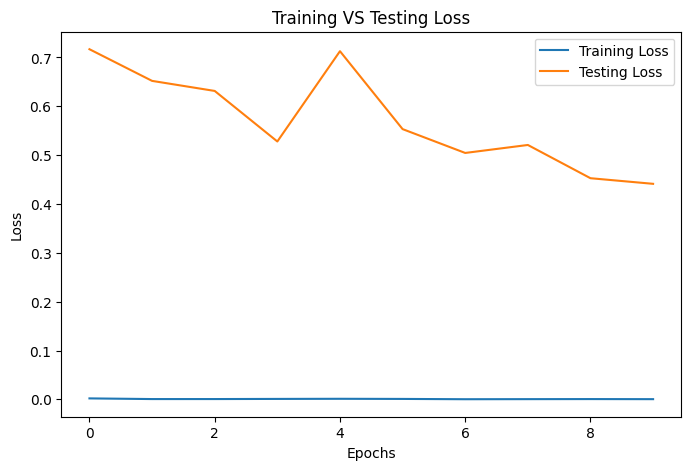

In [34]:
epochs = range(len(model_results['training_loss']))
plt.figure(figsize=(8, 5))
plt.plot(epochs, model_results['training_loss'], label='Training Loss')
plt.plot(epochs, model_results['testing_loss'], label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training VS Testing Loss')
plt.legend()
plt.show()

In [35]:
model.eval()
with torch.no_grad():
    all_embeddings, _ = model(torch.tensor(X_df.values, dtype=torch.float32))

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_clients(user_input, all_embeddings, df_original, top_n=5):

    # Preproces using pipeline
    user_input_processed = pipeline.transform(user_input)
    user_input_tensor = torch.tensor(user_input_processed, dtype=torch.float32)

    # Passing through encoder
    model.eval()
    with torch.no_grad():
        user_embedding, _ = model(user_input_tensor)

    # Computinge cosine similarity
    similarity_scores = cosine_similarity(user_embedding.numpy(), all_embeddings.numpy())[0]

    # Get top N indices
    top_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    return df_original.iloc[top_indices], similarity_scores[top_indices]


In [37]:
sample_input = df.iloc[[10]]
top_clients, scores = recommend_similar_clients(sample_input, all_embeddings, df, top_n=5)
top_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
2487,4432,1,1,2,0,0,1,2,26-100,60.0,...,1,3.0,1.0,5.0,261.0,6.0,4.0,2.0,0.0,0.0
2828,4849,1,0,2,0,0,0,1,26-100,0.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3597,6096,1,1,2,0,0,0,1,500-1000,10000.0,...,1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4131,6873,0,1,2,0,0,1,999,1-25,100.0,...,0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1041,2270,1,1,2,0,0,0,1,500-1000,100.0,...,0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
sample_dict = {
    'catcher_id': 1520,
    'jobma_catcher_status': 1,
    'jobma_catcher_type': 1,
    'subscription_status': 2,
    'subscription_type': 0,
    'referral_credit': 0,
    'is_premium': 1,
    'sub_user': 999,
    'company_size': '500-1000',
    'per_sub_user': 100,
    'number_of_logins': 4,
    'jobma_login_status': 0,
    'days_since_login': 2304,
    'wallet_sum': 6974,
    'plan_type': 0,
    'is_unlimited': 0,
    'subscription_sum': 99999,
    'subscription_count': 10,
    'currency': 0,
    'premium_plan_id': 3,
    'pre_recorded_kit_counts': 70,
    'number_of_jobs_posted': 111,
    'number_of_invitations': 1163,
    'number_of_pitcher_applied': 180,
    'pre_rec_interviews_counts': 161,
    'live_interviews_counts': 60,
    'ai_kit_counts': 0,
    'ai_interviews_counts': 0
}

# Convert sample_dict to DataFrame
sample_input2 = pd.DataFrame([sample_dict])

# Get top 5 similar clients
top_clients, scores = recommend_similar_clients(sample_input2, all_embeddings, df, top_n=5)
top_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
1588,3040,1,1,2,0,0,1,0,101-500,100.0,...,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3132,5381,1,1,2,0,0,0,1,101-500,100.0,...,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2570,4534,1,1,1,0,0,1,4,26-100,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2324,4163,1,1,2,0,0,0,1,101-500,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3185,5470,1,1,2,0,0,1,999,26-100,10000.0,...,1,7.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [39]:
sample_dict2 = {
    'catcher_id': 1520,
    'jobma_catcher_status': 1,
    'jobma_catcher_type': 1,
    'subscription_status': 2,
    'subscription_type': 0,
    'referral_credit': 0,
    'is_premium': 1,
    'sub_user': 999,
    'company_size': '1-25',
    'per_sub_user': 100,
    'number_of_logins': 1,
    'jobma_login_status': 0,
    'days_since_login': 2304,
    'wallet_sum': 694,
    'plan_type': 0,
    'is_unlimited': 0,
    'subscription_sum': 99,
    'subscription_count': 1,
    'currency': 0,
    'premium_plan_id': 3,
    'pre_recorded_kit_counts': 7,
    'number_of_jobs_posted': 31,
    'number_of_invitations': 63,
    'number_of_pitcher_applied': 80,
    'pre_rec_interviews_counts': 61,
    'live_interviews_counts': 11,
    'ai_kit_counts': 0,
    'ai_interviews_counts': 0
}

sample_input2 = pd.DataFrame([sample_dict2])
top_clients, scores = recommend_similar_clients(sample_input2, all_embeddings, df, top_n=5)
top_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
1910,3555,1,1,2,0,0,0,1,1-25,60.0,...,1,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1946,3608,1,1,2,0,0,1,5,26-100,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2324,4163,1,1,2,0,0,0,1,101-500,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3185,5470,1,1,2,0,0,1,999,26-100,10000.0,...,1,7.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3132,5381,1,1,2,0,0,0,1,101-500,100.0,...,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
sample_dict3= { 'catcher_id': 1873,
                'jobma_catcher_status': 1,
                'jobma_catcher_type': 1,
                'subscription_status': 1,
                'subscription_type': 0,
                'referral_credit': 1,
                'is_premium': 1,
                'sub_user': 999,
                'company_size': '500-1000',
                'per_sub_user': 100,
                'number_of_logins': 1,
                'jobma_login_status': 0,
                'days_since_login': 22,
                'wallet_sum': 882,
                'plan_type': 0,
                'is_unlimited': 0,
                'subscription_sum': 1243365,
                'subscription_count': 238,
                'currency': 0,
                'premium_plan_id': 4,
                'pre_recorded_kit_counts': 297,
                'number_of_jobs_posted': 547,
                'number_of_invitations': 2539,
                'number_of_pitcher_applied': 728,
                'pre_rec_interviews_counts': 604,
                'live_interviews_counts': 113,
                'ai_kit_counts': 32,
                'ai_interviews_counts': 67
              }

sample_input3 = pd.DataFrame([sample_dict3])
top_clients, scores = recommend_similar_clients(sample_input3, all_embeddings, df, top_n=5)
top_clients

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
1667,3178,1,1,2,0,0,0,1,1-25,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1865,3458,1,1,2,0,0,1,2,26-100,60.0,...,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
639,1400,1,1,2,0,0,1,999,1-25,100.0,...,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2359,4211,1,1,2,0,0,1,2,26-100,100.0,...,0,3.0,1.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0
530,1199,1,1,2,0,0,1,999,1-25,100.0,...,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
df[df['catcher_id']==92].T

,0
catcher_id,92
jobma_catcher_status,1
jobma_catcher_type,1
subscription_status,2
subscription_type,0
referral_credit,0
is_premium,1
sub_user,999
company_size,1-25
per_sub_user,100.0
